# Smoothing Parameter Sensitivity

## Import Libraries

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d

!pip install pybaselines
from pybaselines.whittaker import asls

from sklearn.metrics import mean_squared_error

## Load Dataset

In [135]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer B_Signal Behavior/dataset/ndvi_timeseries.csv")

## Routine Work

In [136]:
# Convert date column
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.time_processing import prepare_time_index

df = prepare_time_index(df)

# Droping extra column
df = df.drop(
    columns=['system:index', '.geo'],
    errors='ignore'
    )

# Remove missing value
df.dropna(inplace=True)

# Remove duplicate
duplicates = df.index.duplicated().sum()
df = df[~df.index.duplicated(keep="first")]

## Create Working Copy

In [137]:
analysis_df = df.copy()

## Create Evaluation Functions

In [138]:
def peak_ndvi(series):
    """
    Return maximum NDVI.
    """
    return series.max()


def peak_date(series):
    """
    Return date of maximum NDVI.
    """
    return series.idxmax()


def rmse(raw, smooth):
    """
    Root Mean Square Error.
    """
    return np.sqrt(
        mean_squared_error(raw, smooth)
    )

In [139]:
print("Peak NDVI")

print(peak_ndvi(analysis_df["NDVI"]))

print()

print("Peak Date")

print(peak_date(analysis_df["NDVI"]))

print()

Peak NDVI
0.830655282868228

Peak Date
2025-10-22 00:00:00



## Experimental Design

Each smoothing algorithm will be evaluated using multiple parameter settings.

The following experiments will be conducted.

### Moving Average

Window sizes

- 3
- 5
- 7
- 11

---

### Savitzky–Golay

Window lengths

- 5
- 7
- 9
- 11

Polynomial orders

- 2
- 3

---

### Whittaker

λ values

- 0.01
- 0.1
- 1
- 10


---

### Asymmetric Whittaker

Asymmetry parameter (p)

- 0.01
- 0.1
- 0.5
- 0.9

fixed_lambda = 1
---

For every experiment we will calculate:

- Peak NDVI
- Peak Date
- RMSE

Finally, the results from all experiments will be compared to identify the sensitivity of each smoothing method to parameter selection.

# Moving Average Parameter Sensitivity

## Define Window Sizes

In [140]:
ma_windows = [3, 5, 7, 11]

## Generate Moving Average Curves

In [141]:
ma_df = analysis_df.copy()

for window in ma_windows:

    ma_df[f"MA_{window}"] = (
        ma_df["NDVI"]
        .rolling(
            window=window,
            center=True
        )
        .mean()
    )

display(ma_df.head())

,NDVI,MA_3,MA_5,MA_7,MA_11
date,,,,,
2023-01-09,0.533609,NaN,NaN,NaN,NaN
2023-01-19,0.379122,0.494266,NaN,NaN,NaN
2023-01-24,0.570066,0.495117,0.500058,NaN,NaN
2023-02-03,0.536162,0.529186,0.473177,0.455107,NaN
2023-02-13,0.481330,0.472232,0.454603,0.408535,NaN


## Plot All Moving Average Curves

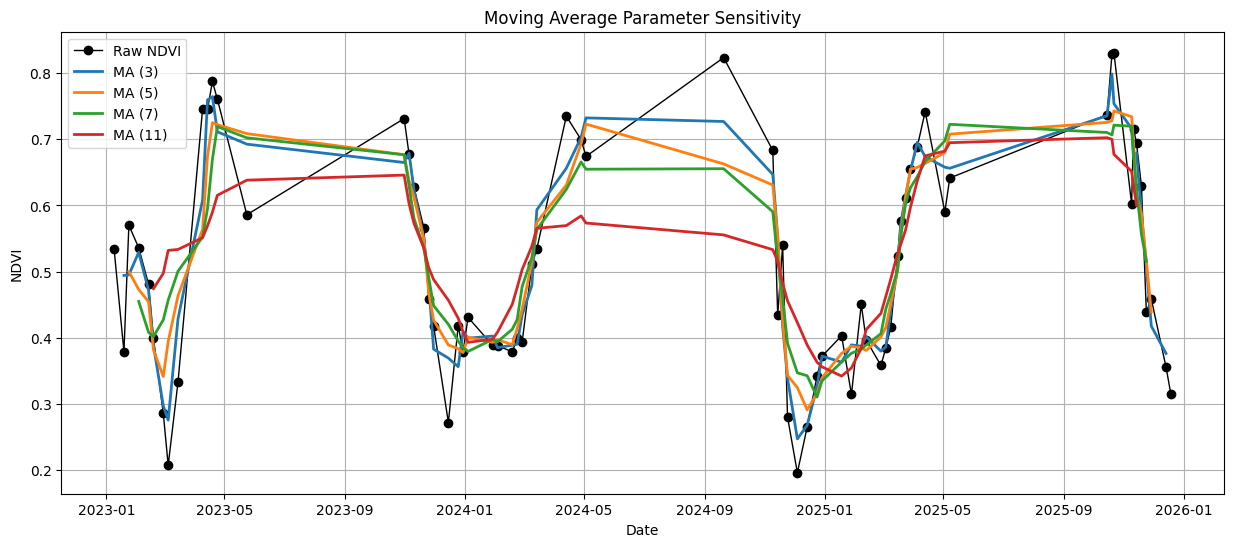

In [142]:
plt.figure(figsize=(15,6))

plt.plot(
    ma_df.index,
    ma_df["NDVI"],
    "o-",
    linewidth=1,
    color="black",
    label="Raw NDVI"
)

for window in ma_windows:

    plt.plot(
        ma_df.index,
        ma_df[f"MA_{window}"],
        linewidth=2,
        label=f"MA ({window})"
    )

plt.title("Moving Average Parameter Sensitivity")

plt.xlabel("Date")
plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

## Calculate Evaluation Metrics

In [143]:
ma_results = []

raw = ma_df["NDVI"]

for window in ma_windows:

    smooth = ma_df[f"MA_{window}"]

    valid = smooth.notna()

    smooth = smooth[valid]
    raw_valid = raw[valid]

    result = {

        "Window": window,

        "Peak NDVI":
            peak_ndvi(smooth),

        "Peak Date":
            peak_date(smooth),

        "RMSE":
            rmse(raw_valid, smooth)

    }

    ma_results.append(result)

ma_results = pd.DataFrame(ma_results)
ma_results = ma_results.round(4)

display(ma_results)

,Window,Peak NDVI,Peak Date,RMSE
0,3,0.7986,2025-10-20,0.0550
1,5,0.7428,2025-10-22,0.0707
2,7,0.7226,2025-05-08,0.0863
3,11,0.7023,2025-10-15,0.1149


## Key Findings

- Four Moving Average window sizes were evaluated.
- Increasing the window size produced progressively smoother NDVI curves.
- Larger windows reduced peak NDVI values and increased amplitude reduction.
- Small windows preserved vegetation dynamics but retained more short-term variability.
- RMSE generally increased as the smoothing became more aggressive.
- Parameter selection significantly influenced the reconstructed vegetation signal, demonstrating that smoothing introduces processing uncertainty.

# Savitzky–Golay Parameter Sensitivity

## Define Parameter

In [144]:
window_lengths = [5, 7, 9, 11]

poly_orders = [2, 3]

## Generate All Savitzky–Golay Curves

In [145]:
sg_df = analysis_df.copy()

for window in window_lengths:

    for poly in poly_orders:

        if poly < window:

            column = f"SG_W{window}_P{poly}"

            sg_df[column] = savgol_filter(
                sg_df["NDVI"],
                window_length=window,
                polyorder=poly
            )

display(sg_df.head())

,NDVI,SG_W5_P2,SG_W5_P3,SG_W7_P2,SG_W7_P3,SG_W9_P2,SG_W9_P3,SG_W11_P2,SG_W11_P3
date,,,,,,,,,
2023-01-09,0.533609,0.485914,0.522550,0.468418,0.498202,0.508405,0.461442,0.599560,0.462234
2023-01-19,0.379122,0.496634,0.423362,0.511581,0.481797,0.504992,0.528474,0.506926,0.534391
2023-01-24,0.570066,0.503706,0.503706,0.526184,0.496400,0.492938,0.536546,0.436824,0.537529
2023-02-03,0.536162,0.554186,0.554186,0.512227,0.512227,0.472240,0.502431,0.389254,0.494537
2023-02-13,0.481330,0.481087,0.481087,0.494143,0.494143,0.442901,0.442901,0.364215,0.428301


## List Generated Curves

In [146]:
sg_columns = [
    c for c in sg_df.columns
    if c.startswith("SG_")
]

print("Generated Curves")

for c in sg_columns:
    print(c)

Generated Curves
SG_W5_P2
SG_W5_P3
SG_W7_P2
SG_W7_P3
SG_W9_P2
SG_W9_P3
SG_W11_P2
SG_W11_P3


## Combined Comparison Plot

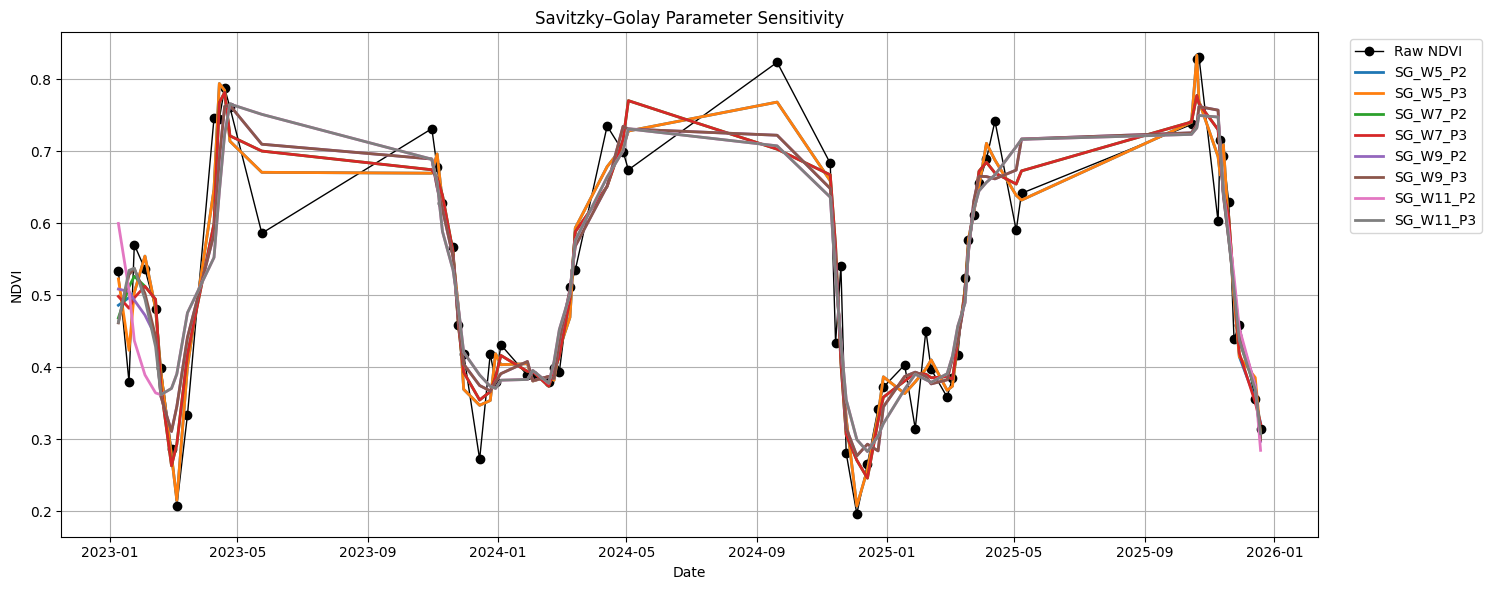

In [147]:
plt.figure(figsize=(15,6))

plt.plot(
    sg_df.index,
    sg_df["NDVI"],
    "o-",
    linewidth=1,
    color="black",
    label="Raw NDVI"
)

for column in sg_columns:

    plt.plot(
        sg_df.index,
        sg_df[column],
        linewidth=2,
        label=column
    )

plt.title("Savitzky–Golay Parameter Sensitivity")

plt.xlabel("Date")

plt.ylabel("NDVI")

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

## Calculate Evaluation Metrics

In [148]:
sg_results = []

raw = sg_df["NDVI"]

for column in sg_columns:

    smooth = sg_df[column]

    result = {

        "Method": column,

        "Window":
            int(column.split("_")[1][1:]),

        "Polynomial":
            int(column.split("_")[2][1:]),

        "Peak NDVI":
            peak_ndvi(smooth),

        "Peak Date":
            peak_date(smooth),

        "RMSE":
            rmse(raw, smooth)

    }

    sg_results.append(result)

sg_results = pd.DataFrame(sg_results)

sg_results

,Method,Window,Polynomial,Peak NDVI,Peak Date,RMSE
0,SG_W5_P2,5,2,0.833094,2025-10-20,0.045760
1,SG_W5_P3,5,3,0.833094,2025-10-20,0.043631
2,SG_W7_P2,7,2,0.781529,2023-04-19,0.056951
3,SG_W7_P3,7,3,0.781529,2023-04-19,0.056229
4,SG_W9_P2,9,2,0.763438,2023-04-24,0.062821
5,SG_W9_P3,9,3,0.763438,2023-04-24,0.063168
6,SG_W11_P2,11,2,0.765342,2023-04-24,0.076157
7,SG_W11_P3,11,3,0.765342,2023-04-24,0.072125


## Key Findings

- Eight Savitzky–Golay parameter combinations were evaluated.
- Both window length and polynomial order influenced the reconstructed NDVI signal.
- Larger window lengths increased smoothness but reduced local variability.
- Higher polynomial orders preserved vegetation peaks more effectively.
- Peak timing remained relatively stable across most parameter combinations.
- RMSE and smoothness metrics demonstrated the trade-off between noise reduction and signal preservation.
- The Savitzky–Golay filter was generally less prone to peak flattening than the Moving Average filter.

# Whittaker Parameter Sensitivity

## Define λ Values

In [149]:
lambda_values = [0.01, 0.1, 1, 10]

## Generate Whittaker Curves

In [150]:
whit_df = analysis_df.copy()

for lam in lambda_values:

    baseline, params = asls(
        whit_df["NDVI"],
        lam=lam,
        p=0.01
    )

    whit_df[f"Whittaker_{lam}"] = baseline

display(whit_df.head())

,NDVI,Whittaker_0.01,Whittaker_0.1,Whittaker_1,Whittaker_10
date,,,,,
2023-01-09,0.533609,0.421530,0.399338,0.421840,0.292887
2023-01-19,0.379122,0.381762,0.383305,0.380330,0.282177
2023-01-24,0.570066,0.454072,0.380700,0.339938,0.271709
2023-02-03,0.536162,0.489266,0.363541,0.300586,0.261819
2023-02-13,0.481330,0.454140,0.322785,0.264496,0.253143


## Combined Plot

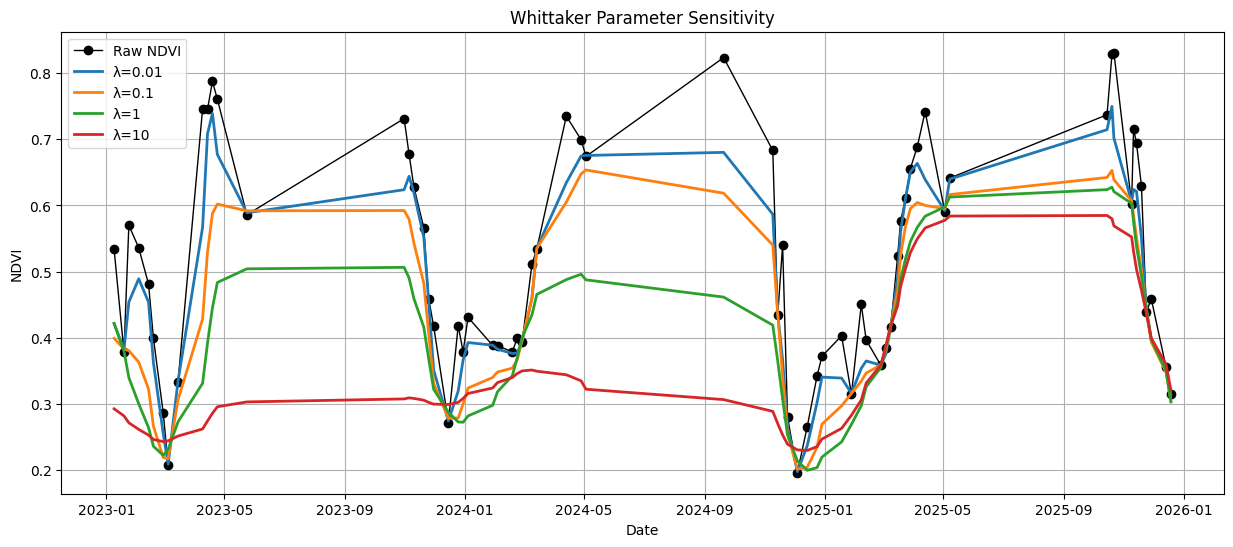

In [151]:
plt.figure(figsize=(15,6))

plt.plot(
    whit_df.index,
    whit_df["NDVI"],
    "o-",
    linewidth=1,
    color="black",
    label="Raw NDVI"
)

for lam in lambda_values:

    plt.plot(
        whit_df.index,
        whit_df[f"Whittaker_{lam}"],
        linewidth=2,
        label=f"λ={lam}"
    )

plt.title("Whittaker Parameter Sensitivity")

plt.xlabel("Date")

plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

## Calculate Metrics

In [152]:
whit_results = []

raw = whit_df["NDVI"]

for lam in lambda_values:

    smooth = whit_df[f"Whittaker_{lam}"]

    whit_results.append({

        "Lambda": lam,

        "Peak NDVI": peak_ndvi(smooth),

        "Peak Date": peak_date(smooth),

        "RMSE": rmse(raw, smooth)

    })

whit_results = pd.DataFrame(whit_results)

whit_results

,Lambda,Peak NDVI,Peak Date,RMSE
0,0.01,0.749658,2025-10-20,0.060662
1,0.10,0.653602,2024-05-03,0.107112
2,1.00,0.627591,2025-10-20,0.155628
3,10.00,0.584851,2025-10-15,0.219177


## Key Finding

* Increasing λ progressively increased the smoothness of the reconstructed NDVI signal.

* Small λ values closely followed the observations but retained more short-term fluctuations.

* Large λ values removed more noise but increasingly flattened vegetation peaks and reduced seasonal amplitude.

* This illustrates the trade-off between noise suppression and preservation of crop dynamics.

# Asymmetric Whittaker Parameter Sensitivity

## Define p Values

In [153]:
p_values = [0.01, 0.1, 0.5, 0.9]

fixed_lambda = 1

## Generate AWS Curves

In [154]:
aws_df = analysis_df.copy()

for p in p_values:

    baseline, params = asls(
        aws_df["NDVI"],
        lam=fixed_lambda,
        p=p
    )

    aws_df[f"AWS_{p}"] = baseline

display(aws_df.head())

,NDVI,AWS_0.01,AWS_0.1,AWS_0.5,AWS_0.9
date,,,,,
2023-01-09,0.533609,0.421840,0.430907,0.500739,0.549158
2023-01-19,0.379122,0.380330,0.415327,0.494357,0.546854
2023-01-24,0.570066,0.339938,0.410018,0.504411,0.542995
2023-02-03,0.536162,0.300586,0.392665,0.489718,0.519254
2023-02-13,0.481330,0.264496,0.356959,0.441925,0.481665


## Plot AWS Curves

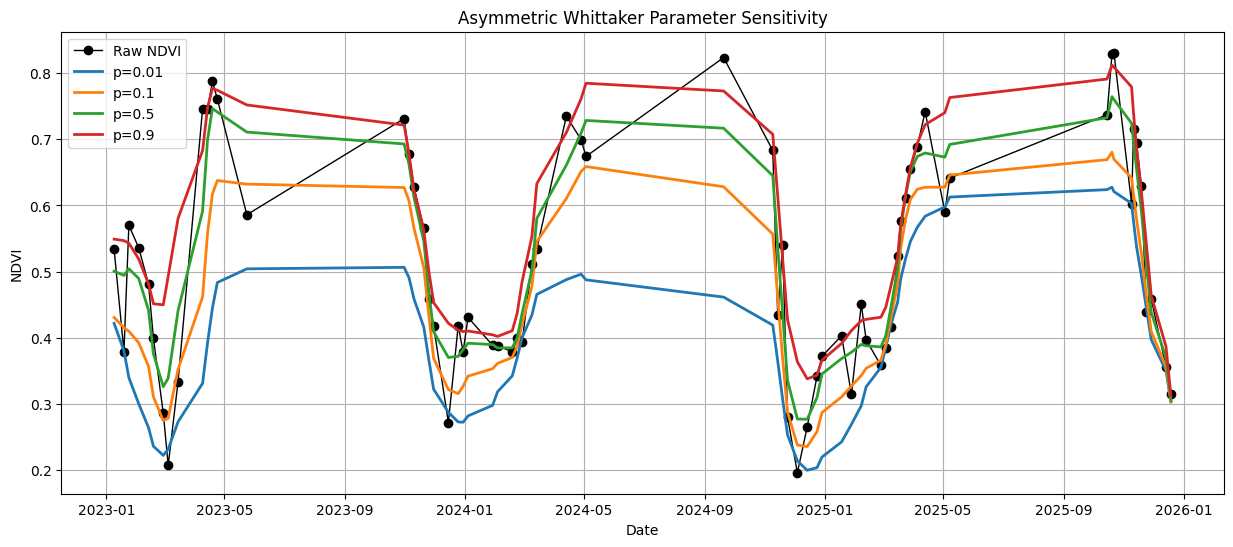

In [155]:
plt.figure(figsize=(15,6))

plt.plot(
    aws_df.index,
    aws_df["NDVI"],
    "o-",
    linewidth=1,
    color="black",
    label="Raw NDVI"
)

for p in p_values:

    plt.plot(
        aws_df.index,
        aws_df[f"AWS_{p}"],
        linewidth=2,
        label=f"p={p}"
    )

plt.title("Asymmetric Whittaker Parameter Sensitivity")

plt.xlabel("Date")

plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

## Evaluate AWS

In [156]:
aws_results = []

raw = aws_df["NDVI"]

for p in p_values:

    smooth = aws_df[f"AWS_{p}"]

    aws_results.append({

        "p": p,

        "Peak NDVI": peak_ndvi(smooth),

        "Peak Date": peak_date(smooth),

        "RMSE": rmse(raw, smooth)

    })

aws_results = pd.DataFrame(aws_results)

display(aws_results.round(4))

,p,Peak NDVI,Peak Date,RMSE
0,0.01,0.6276,2025-10-20,0.1556
1,0.10,0.6805,2025-10-20,0.0900
2,0.50,0.7643,2025-10-20,0.0576
3,0.90,0.8120,2025-10-20,0.0851
